✓ Reddit API connected
✓ NewsAPI connected

Sentiment Collector initialized for 12 tickers
Output directory: sentiment_data

COLLECTING SENTIMENT DATA (30 days back)

[RDDT] Collecting sentiment...
    ⚠️  NewsAPI error: {'status': 'error', 'code': 'apiKeyInvalid', 'message': 'Your API key is invalid or incorrect. Check your key, or go to https://newsapi.org to create a free API key.'}
  Reddit: 0.140 (32 posts)
  News: 0.175 (30 articles)
  Combined: 0.157

[NVDA] Collecting sentiment...
    ⚠️  NewsAPI error: {'status': 'error', 'code': 'apiKeyInvalid', 'message': 'Your API key is invalid or incorrect. Check your key, or go to https://newsapi.org to create a free API key.'}
  Reddit: 0.195 (117 posts)
  News: 0.178 (30 articles)
  Combined: 0.187

[MU] Collecting sentiment...
    ⚠️  NewsAPI error: {'status': 'error', 'code': 'apiKeyInvalid', 'message': 'Your API key is invalid or incorrect. Check your key, or go to https://newsapi.org to create a free API key.'}
  Reddit: 0.144 (29 

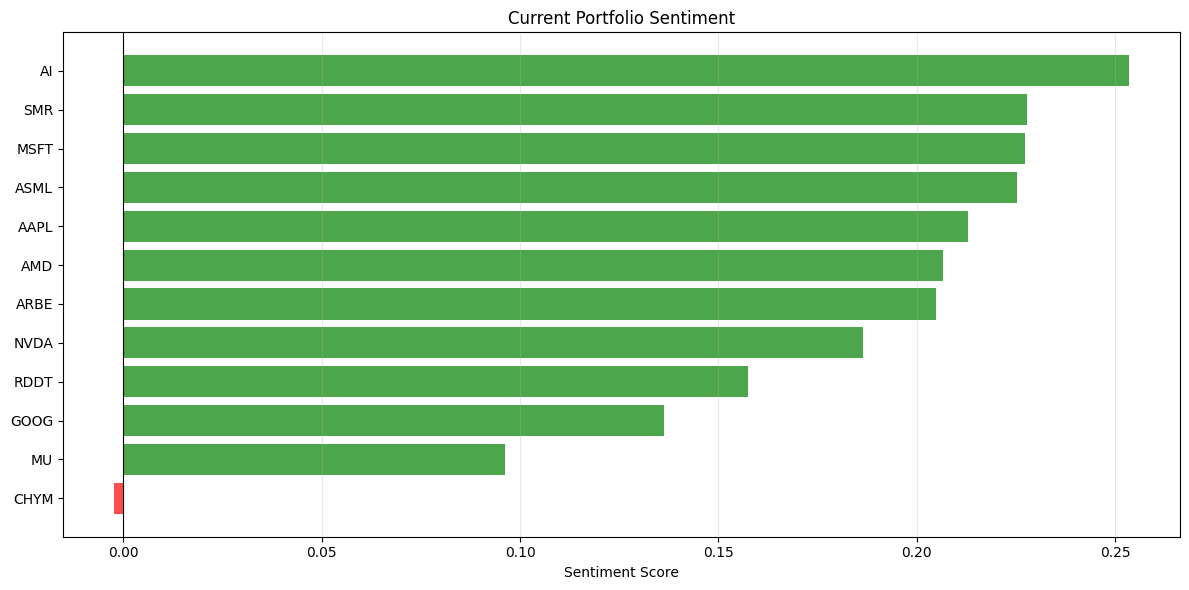

In [2]:
"""
Real Sentiment Data Collection - Reddit & Google News
======================================================

Collects sentiment data for your portfolio tickers from:
1. Reddit (r/wallstreetbets, r/stocks, r/investing)
2. Google News (via RSS feeds)

This replaces the simulated sentiment in data_preparation_part1.py with real data.

Requirements:
- pip install praw vaderSentiment feedparser newsapi-python requests beautifulsoup4

Setup:
1. Get Reddit API credentials: https://www.reddit.com/prefs/apps
2. (Optional) Get NewsAPI key: https://newsapi.org/
"""

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from pathlib import Path
import json
import time
import warnings
warnings.filterwarnings('ignore')

# Sentiment analysis
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Reddit
try:
    import praw
    PRAW_AVAILABLE = True
except ImportError:
    PRAW_AVAILABLE = False
    print("⚠️  PRAW not installed. Install: pip install praw")

# Google News (RSS feeds - no API key needed!)
try:
    import feedparser
    import requests
    from bs4 import BeautifulSoup
    FEEDPARSER_AVAILABLE = True
except ImportError:
    FEEDPARSER_AVAILABLE = False
    print("⚠️  feedparser/requests not installed. Install: pip install feedparser requests beautifulsoup4")

# NewsAPI (requires API key, more comprehensive)
try:
    from newsapi import NewsApiClient
    NEWSAPI_AVAILABLE = True
except ImportError:
    NEWSAPI_AVAILABLE = False
    print("⚠️  NewsAPI not installed. Install: pip install newsapi-python")


class SentimentDataCollector:
    """Collects sentiment data from Reddit and news sources."""
    
    def __init__(
        self,
        tickers: list,
        reddit_client_id: str = None,
        reddit_client_secret: str = None,
        reddit_user_agent: str = None,
        newsapi_key: str = None,
        output_dir: str = 'sentiment_data',
    ):
        """
        Initialize sentiment data collector.
        
        Parameters
        ----------
        tickers : list
            List of stock tickers
        reddit_client_id : str, optional
            Reddit API client ID
        reddit_client_secret : str, optional
            Reddit API client secret
        reddit_user_agent : str, optional
            Reddit API user agent (e.g., "PortfolioBot/1.0")
        newsapi_key : str, optional
            NewsAPI key (optional, can use RSS feeds instead)
        output_dir : str
            Directory to save sentiment data
        """
        self.tickers = [t.upper() for t in tickers]
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(exist_ok=True)
        
        # Initialize sentiment analyzer
        self.analyzer = SentimentIntensityAnalyzer()
        
        # Initialize Reddit
        self.reddit = None
        if PRAW_AVAILABLE and reddit_client_id and reddit_client_secret:
            try:
                self.reddit = praw.Reddit(
                client_id="pLqfk1M1ymfj3ih1NrVFlA",
                client_secret="_hl1434FeTi9kgv_GXAi5tBLoCaLIQ",
                user_agent="SentimentAnalysisBot"
                )
                print("✓ Reddit API connected")
            except Exception as e:
                print(f"⚠️  Reddit API error: {e}")
        else:
            print("⚠️  Reddit API not configured (provide credentials)")
        
        # Initialize NewsAPI
        self.newsapi = None
        if NEWSAPI_AVAILABLE and newsapi_key:
            try:
                self.newsapi = NewsApiClient(api_key=newsapi_key)
                print("✓ NewsAPI connected")
            except Exception as e:
                print(f"⚠️  NewsAPI error: {e}")
        else:
            print("⚠️  NewsAPI not configured (will use RSS feeds)")
        
        # Subreddits to monitor
        self.subreddits = ['wallstreetbets', 'stocks', 'investing', 'StockMarket']
        
        print(f"\nSentiment Collector initialized for {len(tickers)} tickers")
        print(f"Output directory: {self.output_dir}")
    
    def collect_all(self, days_back: int = 30, save: bool = True):
        """
        Collect sentiment from all sources.
        
        Parameters
        ----------
        days_back : int
            Number of days to look back
        save : bool
            Whether to save results
        
        Returns
        -------
        sentiment_df : pd.DataFrame
            Sentiment data for all tickers
        """
        print(f"\n{'='*70}")
        print(f"COLLECTING SENTIMENT DATA ({days_back} days back)")
        print(f"{'='*70}")
        
        all_sentiments = []
        
        for ticker in self.tickers:
            print(f"\n[{ticker}] Collecting sentiment...")
            
            # Collect from Reddit
            reddit_sentiment = self._collect_reddit_sentiment(ticker, days_back)
            
            # Collect from News
            news_sentiment = self._collect_news_sentiment(ticker, days_back)
            
            # Combine
            ticker_sentiment = {
                'ticker': ticker,
                'reddit_sentiment': reddit_sentiment['sentiment'],
                'reddit_posts': reddit_sentiment['n_posts'],
                'reddit_comments': reddit_sentiment['n_comments'],
                'news_sentiment': news_sentiment['sentiment'],
                'news_articles': news_sentiment['n_articles'],
                'combined_sentiment': self._combine_sentiments(reddit_sentiment, news_sentiment),
                'timestamp': datetime.now().isoformat()
            }
            
            all_sentiments.append(ticker_sentiment)
            
            print(f"  Reddit: {reddit_sentiment['sentiment']:.3f} ({reddit_sentiment['n_posts']} posts)")
            print(f"  News: {news_sentiment['sentiment']:.3f} ({news_sentiment['n_articles']} articles)")
            print(f"  Combined: {ticker_sentiment['combined_sentiment']:.3f}")
            
            # Be nice to APIs
            time.sleep(2)
        
        # Create DataFrame
        sentiment_df = pd.DataFrame(all_sentiments)
        
        if save:
            timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
            output_path = self.output_dir / f'sentiment_{timestamp}.csv'
            sentiment_df.to_csv(output_path, index=False)
            print(f"\n✓ Sentiment data saved to {output_path}")
        
        print(f"\n{'='*70}")
        print("SENTIMENT COLLECTION COMPLETE")
        print(f"{'='*70}\n")
        
        return sentiment_df
    
    def _collect_reddit_sentiment(self, ticker: str, days_back: int):
        """Collect sentiment from Reddit."""
        if not self.reddit:
            return {'sentiment': 0.0, 'n_posts': 0, 'n_comments': 0}
        
        sentiments = []
        n_posts = 0
        n_comments = 0
        cutoff_date = datetime.now() - timedelta(days=days_back)
        
        try:
            # Search multiple subreddits
            for subreddit_name in self.subreddits:
                try:
                    subreddit = self.reddit.subreddit(subreddit_name)
                    
                    # Search for ticker mentions
                    query = f"${ticker} OR {ticker}"
                    
                    # Get recent posts
                    for submission in subreddit.search(query, time_filter='month', limit=50):
                        post_date = datetime.fromtimestamp(submission.created_utc)
                        
                        if post_date < cutoff_date:
                            continue
                        
                        # Analyze post title and text
                        text = f"{submission.title} {submission.selftext}"
                        if len(text.strip()) > 10:
                            sentiment = self.analyzer.polarity_scores(text)
                            sentiments.append(sentiment['compound'])
                            n_posts += 1
                        
                        # Analyze top comments
                        try:
                            submission.comments.replace_more(limit=0)
                            for comment in submission.comments[:10]:  # Top 10 comments
                                if hasattr(comment, 'body') and len(comment.body) > 10:
                                    sentiment = self.analyzer.polarity_scores(comment.body)
                                    sentiments.append(sentiment['compound'])
                                    n_comments += 1
                        except:
                            pass
                    
                    time.sleep(1)  # Rate limiting
                    
                except Exception as e:
                    print(f"    ⚠️  Error in r/{subreddit_name}: {e}")
                    continue
        
        except Exception as e:
            print(f"    ⚠️  Reddit error: {e}")
        
        avg_sentiment = np.mean(sentiments) if sentiments else 0.0
        
        return {
            'sentiment': float(avg_sentiment),
            'n_posts': n_posts,
            'n_comments': n_comments
        }
    
    def _collect_news_sentiment(self, ticker: str, days_back: int):
        """Collect sentiment from news sources."""
        sentiments = []
        n_articles = 0
        
        # Try NewsAPI first (if available)
        if self.newsapi:
            try:
                from_date = (datetime.now() - timedelta(days=days_back)).strftime('%Y-%m-%d')
                
                articles = self.newsapi.get_everything(
                    q=ticker,
                    from_param=from_date,
                    language='en',
                    sort_by='relevancy',
                    page_size=50
                )
                
                for article in articles.get('articles', []):
                    text = f"{article.get('title', '')} {article.get('description', '')}"
                    if len(text.strip()) > 10:
                        sentiment = self.analyzer.polarity_scores(text)
                        sentiments.append(sentiment['compound'])
                        n_articles += 1
                
            except Exception as e:
                print(f"    ⚠️  NewsAPI error: {e}")
        
        # Use Google News RSS (free, no API key needed!)
        if FEEDPARSER_AVAILABLE and n_articles < 10:  # If we didn't get enough from NewsAPI
            try:
                # Google News RSS feed
                url = f"https://news.google.com/rss/search?q={ticker}+stock&hl=en-US&gl=US&ceid=US:en"
                
                feed = feedparser.parse(url)
                
                for entry in feed.entries[:30]:  # Get up to 30 articles
                    text = f"{entry.get('title', '')} {entry.get('summary', '')}"
                    if len(text.strip()) > 10:
                        sentiment = self.analyzer.polarity_scores(text)
                        sentiments.append(sentiment['compound'])
                        n_articles += 1
                
            except Exception as e:
                print(f"    ⚠️  Google News RSS error: {e}")
        
        avg_sentiment = np.mean(sentiments) if sentiments else 0.0
        
        return {
            'sentiment': float(avg_sentiment),
            'n_articles': n_articles
        }
    
    def _combine_sentiments(self, reddit_data, news_data):
        """Combine Reddit and news sentiment with weighting."""
        # Weight based on data availability
        reddit_weight = min(reddit_data['n_posts'] + reddit_data['n_comments'], 50) / 50
        news_weight = min(news_data['n_articles'], 20) / 20
        
        total_weight = reddit_weight + news_weight
        
        if total_weight == 0:
            return 0.0
        
        combined = (
            reddit_data['sentiment'] * reddit_weight +
            news_data['sentiment'] * news_weight
        ) / total_weight
        
        return float(combined)
    
    def create_time_series(
        self,
        start_date: str,
        end_date: str = None,
        frequency: str = 'W',
        save: bool = True
    ):
        """
        Create time series of sentiment data by collecting periodically.
        
        This is a helper to create historical sentiment data.
        In production, you'd run this script weekly to build up history.
        
        Parameters
        ----------
        start_date : str
            Start date (YYYY-MM-DD)
        end_date : str, optional
            End date (default: today)
        frequency : str
            'W' for weekly, 'D' for daily
        save : bool
            Save to CSV
        
        Returns
        -------
        sentiment_ts : pd.DataFrame
            Time series of sentiment data
        """
        print(f"\n{'='*70}")
        print("CREATING SENTIMENT TIME SERIES")
        print(f"{'='*70}")
        print("NOTE: This collects CURRENT sentiment for each date.")
        print("For true historical sentiment, run this script weekly and accumulate data.")
        print(f"{'='*70}\n")
        
        start = pd.to_datetime(start_date)
        end = pd.to_datetime(end_date) if end_date else pd.Timestamp.now()
        
        # Create date range
        if frequency == 'W':
            dates = pd.date_range(start, end, freq='W-FRI')
        else:
            dates = pd.date_range(start, end, freq='D')
        
        all_data = []
        
        for date in dates:
            print(f"\nCollecting sentiment as of {date.date()}...")
            
            # Collect sentiment (looking back 7 days for weekly, 1 day for daily)
            days_back = 7 if frequency == 'W' else 1
            sentiment_df = self.collect_all(days_back=days_back, save=False)
            
            # Add date
            sentiment_df['date'] = date
            
            all_data.append(sentiment_df)
            
            # Rate limiting
            time.sleep(5)
        
        # Combine all dates
        sentiment_ts = pd.concat(all_data, ignore_index=True)
        
        if save:
            output_path = self.output_dir / 'sentiment_time_series.csv'
            sentiment_ts.to_csv(output_path, index=False)
            print(f"\n✓ Time series saved to {output_path}")
        
        return sentiment_ts


def example_usage():
    """Example usage with your portfolio."""
    
    # Your portfolio
    PORTFOLIO = ['RDDT', 'NVDA', 'MU', 'AAPL', 'SMR', 'AMD', 'ASML', 'MSFT', 'GOOG', 'AI', 'ARBE', 'CHYM']
    
    # Initialize collector
    # IMPORTANT: Replace with your actual credentials!
    collector = SentimentDataCollector(
        tickers=PORTFOLIO,
        
        # Reddit API credentials
        # Get them here: https://www.reddit.com/prefs/apps
        reddit_client_id='YOUR_REDDIT_CLIENT_ID',
        reddit_client_secret='YOUR_REDDIT_CLIENT_SECRET',
        reddit_user_agent='PortfolioBot/1.0',
        
        # NewsAPI key (optional, RSS feeds work without it)
        # Get free key: https://newsapi.org/
        newsapi_key='YOUR_NEWSAPI_KEY',  # or None
        
        output_dir='sentiment_data'
    )
    
    # Collect current sentiment (last 30 days)
    sentiment_df = collector.collect_all(days_back=30, save=True)
    
    print("\n" + "="*70)
    print("SENTIMENT SUMMARY")
    print("="*70)
    print(sentiment_df[['ticker', 'combined_sentiment', 'reddit_posts', 'news_articles']].to_string(index=False))
    
    # Visualize
    try:
        import matplotlib.pyplot as plt
        
        fig, ax = plt.subplots(figsize=(12, 6))
        
        sentiment_df = sentiment_df.sort_values('combined_sentiment')
        colors = ['red' if x < 0 else 'green' for x in sentiment_df['combined_sentiment']]
        
        ax.barh(sentiment_df['ticker'], sentiment_df['combined_sentiment'], color=colors, alpha=0.7)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Sentiment Score')
        ax.set_title('Current Portfolio Sentiment')
        ax.grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('sentiment_data/sentiment_chart.png', dpi=150)
        print("\n✓ Chart saved to sentiment_data/sentiment_chart.png")
        
    except ImportError:
        print("\n⚠️  matplotlib not available for visualization")


def setup_credentials():
    """Helper to set up API credentials."""
    print("\n" + "="*70)
    print("SENTIMENT DATA COLLECTOR - CREDENTIAL SETUP")
    print("="*70)
    
    print("\n1. REDDIT API SETUP")
    print("-" * 70)
    print("a. Go to: https://www.reddit.com/prefs/apps")
    print("b. Click 'create another app...' at the bottom")
    print("c. Fill in:")
    print("   - Name: Portfolio Sentiment Bot")
    print("   - Type: Select 'script'")
    print("   - Redirect URI: http://localhost:8080")
    print("d. Click 'create app'")
    print("e. Note down:")
    print("   - Client ID (under app name)")
    print("   - Client Secret")
    
    print("\n2. NEWSAPI SETUP (Optional)")
    print("-" * 70)
    print("a. Go to: https://newsapi.org/")
    print("b. Click 'Get API Key'")
    print("c. Sign up for free account")
    print("d. Copy your API key")
    print("e. Note: Free tier = 100 requests/day (sufficient)")
    
    print("\n3. GOOGLE NEWS RSS (No setup needed!)")
    print("-" * 70)
    print("✓ Uses public RSS feeds, no API key required")
    
    print("\n4. UPDATE THE SCRIPT")
    print("-" * 70)
    print("Replace these lines in example_usage():")
    print("  reddit_client_id='YOUR_REDDIT_CLIENT_ID'")
    print("  reddit_client_secret='YOUR_REDDIT_CLIENT_SECRET'")
    print("  newsapi_key='YOUR_NEWSAPI_KEY'  # or None to skip")
    
    print("\n" + "="*70)
    print("Once credentials are set up, run: python collect_sentiment_data.py")
    print("="*70 + "\n")


if __name__ == '__main__':
    import sys
    
    if len(sys.argv) > 1 and sys.argv[1] == '--setup':
        # Show setup instructions
        setup_credentials()
    else:
        # Run collection
        example_usage()